# REV1-03 — Event-Window SPI untuk Driver Flash Drought (Christian-style) — v2 FIXED

## Tujuan

Notebook ini menambahkan **SPI pada sisi suplai presipitasi** untuk setiap *grid-cell flash-drought start* yang sudah dideteksi oleh benchmark RZSM/M2A.

**Notebook ini tidak mendeteksi ulang flash drought.** Inventori FD tetap berasal dari RZSM. SPI hanya dipakai untuk menjawab:

> Apakah selama fase *rapid development* suatu FD terjadi defisit presipitasi yang besar dibanding klimatologi pada grid, musim, dan panjang perkembangan yang sama?

### Dasar metode

Christian et al. (2021, *Nature Communications*, DOI: 10.1038/s41467-021-26692-z) menghitung akumulasi presipitasi selama *time frame of flash drought development*, kemudian menghitung SPI menggunakan klimatologi presipitasi pada *time frame* yang sama. Ambang `SPI <= -1` digunakan untuk menandai defisit presipitasi besar.

Di workflow ini, karena detector RZSM mendefinisikan:

- `t0` = baseline terakhir dengan RZSM ≥ P40,
- `onset_time_pentads` = jumlah interval dari baseline sampai pertama kali RZSM < P20,

maka **jendela driver presipitasi** didefinisikan sebagai pentad **setelah baseline hingga threshold crossing**, yaitu:

`[t0+1, ..., t0+onset_time_pentads]`

Dengan demikian panjang akumulasi presipitasi = `onset_time_pentads` pentad. Jendela yang sama nanti harus digunakan untuk PET agar klasifikasi SPI–PET benar-benar sebanding.

### Catatan penting

- SPI di sini adalah **event-window SPI**, bukan SPI bulanan tetap seperti SPI-1 atau SPI-3.
- Distribusi gamma digunakan mengikuti formulasi SPI klasik McKee et al. (1993, 1995), termasuk koreksi probabilitas nol.
- Setiap event dibandingkan dengan distribusi akumulasi presipitasi pada **grid yang sama, baseline calendar-pentad yang sama, dan panjang rapid-development yang sama** selama periode klimatologi 1995–2025.
- Hasil adalah **diagnostik asosiasi meteorologis**, bukan atribusi kausal.


In [1]:
from pathlib import Path
import json
import re
import warnings

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

from scipy.special import gammainc
from scipy.stats import norm

warnings.filterwarnings("once")

# ============================================================
# PATH & PARAMETER
# ============================================================

BASE = Path(r"D:\ERA5_LAND")

DETECTION_FILE = (
    BASE / "output_fd_03b_sensitivity"
    / "fd_detection_M2A_1995_2025_indonesia.nc"
)

EVENT_DIR = BASE / "output_fd_REV1_01_event_level_drivers"
EVENT_PARQUET = EVENT_DIR / "event_level_driver_table_RAW.parquet"
EVENT_CSV_GZ = EVENT_DIR / "event_level_driver_table_RAW.csv.gz"

PRECIP_DIR = (
    BASE / "output_fd_04_drivers"
    / "yearly_pentad"
)

OUTPUT_DIR = BASE / "output_fd_REV1_03_SPI"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

ANALYSIS_START = 1996
ANALYSIS_END = 2024

CLIM_START = 1995
CLIM_END = 2025
CLIM_YEARS = np.arange(CLIM_START, CLIM_END + 1)

SPI_THRESHOLD = -1.0
MIN_CLIM_SAMPLES = 25
PROB_EPS = 1e-7

print("Detection :", DETECTION_FILE)
print("Event dir :", EVENT_DIR)
print("Precip dir:", PRECIP_DIR)
print("Output    :", OUTPUT_DIR)
print("Climate   :", CLIM_START, "-", CLIM_END)


Detection : D:\ERA5_LAND\output_fd_03b_sensitivity\fd_detection_M2A_1995_2025_indonesia.nc
Event dir : D:\ERA5_LAND\output_fd_REV1_01_event_level_drivers
Precip dir: D:\ERA5_LAND\output_fd_04_drivers\yearly_pentad
Output    : D:\ERA5_LAND\output_fd_REV1_03_SPI
Climate   : 1995 - 2025


## 1. Load tabel event REV1-01 dan audit deteksi

Notebook memakai tabel event dari REV1-01 agar `event_id` tetap konsisten dengan analisis P–T2m–VPD sebelumnya. File deteksi tetap dibuka untuk memperoleh indeks grid dan kalender kontinu year–pentad.


In [2]:
if EVENT_PARQUET.exists():
    events = pd.read_parquet(EVENT_PARQUET)
    event_source = EVENT_PARQUET
elif EVENT_CSV_GZ.exists():
    events = pd.read_csv(EVENT_CSV_GZ)
    event_source = EVENT_CSV_GZ
else:
    raise FileNotFoundError(
        "Tabel event REV1-01 tidak ditemukan. Jalankan REV1-01 terlebih dahulu."
    )

if not DETECTION_FILE.exists():
    raise FileNotFoundError(DETECTION_FILE)

required_event_cols = [
    "event_id", "time_index", "year", "pentad",
    "latitude", "longitude", "onset_time_pentads"
]
missing = [c for c in required_event_cols if c not in events.columns]
if missing:
    raise KeyError(f"Kolom event wajib tidak ada: {missing}")

# Analisis utama harus sama dengan REV1-01.
events = events[
    (events["year"] >= ANALYSIS_START)
    & (events["year"] <= ANALYSIS_END)
].copy()

events = events.sort_values("event_id").reset_index(drop=True)

if events["event_id"].duplicated().any():
    raise ValueError("event_id tidak unik.")

# onset_time harus integer positif dan maksimum sesuai benchmark M2A.
onset_float = events["onset_time_pentads"].to_numpy(dtype=float)
if not np.all(np.isfinite(onset_float)):
    raise ValueError("Ada onset_time_pentads yang missing/non-finite.")
if not np.allclose(onset_float, np.round(onset_float)):
    raise ValueError("onset_time_pentads harus berupa integer pentad.")

events["onset_time_pentads"] = np.round(onset_float).astype(np.int16)

if (events["onset_time_pentads"] <= 0).any():
    raise ValueError("Ada onset_time_pentads <= 0.")

print("Input kejadian:", event_source)
print("Jumlah baris :", f"{len(events):,}")
print("Tahuns       :", int(events.year.min()), "-", int(events.year.max()))
print("Rentang onset:", int(events.onset_time_pentads.min()), "-", int(events.onset_time_pentads.max()), "pentad")
display(events[required_event_cols].head())


Input kejadian: D:\ERA5_LAND\output_fd_REV1_01_event_level_drivers\event_level_driver_table_RAW.parquet
Jumlah baris : 559,676
Tahuns       : 1996 - 2024
Rentang onset: 1 - 5 pentad


,event_id,time_index,year,pentad,latitude,longitude,onset_time_pentads
0,0,73,1996,1,-8.2,131.000000,2
1,1,73,1996,1,-7.5,110.000000,1
2,2,73,1996,1,-7.2,108.599998,1
3,3,73,1996,1,-7.2,108.699997,1
4,4,73,1996,1,-7.0,111.300003,1


In [3]:
det = xr.open_dataset(DETECTION_FILE, mask_and_scale=False)

required_det = [
    "fd_event_start", "year", "pentad",
    "latitude", "longitude", "valid_grid_mask"
]
missing = [v for v in required_det if v not in det]
if missing:
    raise KeyError(f"Detection file kehilangan: {missing}")

det_year = np.asarray(det["year"].values).astype(int)
det_pentad = np.asarray(det["pentad"].values).astype(int)
lat = np.asarray(det["latitude"].values)
lon = np.asarray(det["longitude"].values)
valid_mask = np.asarray(det["valid_grid_mask"].values == 1, dtype=bool)

analysis_mask = (
    (det["fd_event_start"] == 1)
    & (det["year"] >= ANALYSIS_START)
    & (det["year"] <= ANALYSIS_END)
    & (det["valid_grid_mask"] == 1)
)

t_idx, y_idx, x_idx = np.where(np.asarray(analysis_mask.values, dtype=bool))

if len(t_idx) != len(events):
    raise ValueError(
        f"Jumlah event detection ({len(t_idx):,}) != REV1-01 ({len(events):,})."
    )

# REV1-01 dibentuk dengan urutan np.where yang sama. Audit sebelum memakai indeks grid.
checks = {
    "time_index": np.array_equal(events["time_index"].to_numpy(dtype=int), t_idx),
    "year": np.array_equal(events["year"].to_numpy(dtype=int), det_year[t_idx]),
    "pentad": np.array_equal(events["pentad"].to_numpy(dtype=int), det_pentad[t_idx]),
    "latitude": np.allclose(events["latitude"].to_numpy(dtype=float), lat[y_idx]),
    "longitude": np.allclose(events["longitude"].to_numpy(dtype=float), lon[x_idx]),
}
print("Pemeriksaan keselarasan:", checks)
if not all(checks.values()):
    raise ValueError("Urutan event REV1-01 tidak identik dengan detection file.")

ntime = len(det_year)
time_lookup = pd.DataFrame({
    "time_index": np.arange(ntime, dtype=int),
    "year": det_year,
    "pentad": det_pentad,
})

pair_to_t = {
    (int(y), int(p)): int(t)
    for t, y, p in time_lookup[["time_index", "year", "pentad"]]
    .itertuples(index=False, name=None)
}

print("Grid daratan valid:", f"{valid_mask.sum():,}")
print("Jumlah langkah waktu deteksi:", ntime)


<frozen importlib._bootstrap>:488: RuntimeWarning: numpy.ndarray size changed, may indicate binary incompatibility. Expected 16 from C header, got 96 from PyObject


Pemeriksaan keselarasan: {'time_index': True, 'year': True, 'pentad': True, 'latitude': True, 'longitude': True}
Grid daratan valid: 14,857
Jumlah langkah waktu deteksi: 2263


## 2. Load presipitasi pentad 1995–2025

Kita memakai file yang **sudah dibuat oleh workflow driver lama**:

`D:\ERA5_LAND\output_fd_04_drivers\yearly_pentad\meteorological_drivers_pentad_YYYY.nc`

Jadi tidak ada download presipitasi baru.

Untuk efisiensi, hanya grid Indonesia yang valid pada `valid_grid_mask` yang dimuat ke memori.


In [4]:
def standardize_spatial_names(ds):
    rename = {}
    if "lat" in ds.dims and "latitude" not in ds.dims:
        rename["lat"] = "latitude"
    if "lon" in ds.dims and "longitude" not in ds.dims:
        rename["lon"] = "longitude"
    if rename:
        ds = ds.rename(rename)
    return ds


def find_pentad_dim(da):
    for d in da.dims:
        if d.lower() == "pentad":
            return d
    for d in da.dims:
        if d.lower() in {"time", "time_index"}:
            return d
    for d in da.dims:
        if d not in {"year", "latitude", "longitude"} and 70 <= da.sizes[d] <= 74:
            return d
    raise ValueError(f"Tidak menemukan dimensi pentad pada {da.dims}")


def find_precip_var(ds):
    scored = []
    for v in ds.data_vars:
        name = v.lower()
        text = " ".join([
            name,
            str(ds[v].attrs.get("long_name", "")).lower(),
            str(ds[v].attrs.get("standard_name", "")).lower(),
            str(ds[v].attrs.get("units", "")).lower(),
        ])
        score = 0
        # Prioritaskan TOTAL precipitation, bukan anomaly.
        if name == "tp_mm": score += 100
        if name == "tp": score += 80
        if "anom" in name or "anomaly" in text: score -= 100
        if "precip" in name: score += 25
        if name.startswith("tp_") or name.endswith("_tp"): score += 20
        if "rain" in name: score += 10
        if "precip" in text or "total precipitation" in text: score += 10
        if score > 0:
            scored.append((score, v))
    if not scored:
        return None
    scored.sort(key=lambda z: (-z[0], z[1]))
    return scored[0][1]


def precip_to_mm(da):
    """Konversi presipitasi pentad menjadi mm jika masih dalam meter."""
    units = str(da.attrs.get("units", "")).strip().lower()
    name = str(da.name or "").lower()

    if units in {"m", "meter", "metre", "meters", "metres"}:
        out = da * 1000.0
        out.attrs = da.attrs.copy()
        out.attrs["units"] = "mm"
        return out
    if "mm" in units or "millimeter" in units or "millimetre" in units:
        return da
    if name.endswith("_mm") or "_mm_" in name:
        return da

    raise ValueError(
        f"Unit presipitasi tidak dikenali: variable={da.name}, units='{units}'. "
        "Periksa file yearly pentad sebelum melanjutkan."
    )


def select_year_from_yearly_file(da, expected_year):
    """
    File yearly driver milik workflow lama memiliki dimensi:
    (year=1, pentad, latitude, longitude).

    Untuk SPI kita membutuhkan array 3-D:
    (pentad, latitude, longitude).

    Fungsi ini membuang dimensi year HANYA setelah memastikan
    bahwa isinya memang tahun yang sedang dibaca.
    """
    if "year" not in da.dims:
        return da

    if "year" in da.coords:
        years_here = np.atleast_1d(np.asarray(da["year"].values)).astype(int)
    else:
        years_here = np.array([], dtype=int)

    if da.sizes["year"] == 1:
        if years_here.size == 1 and int(years_here[0]) != int(expected_year):
            raise ValueError(
                f"File untuk {expected_year} ternyata memiliki coordinate year={int(years_here[0])}."
            )
        return da.isel(year=0, drop=True)

    if years_here.size and int(expected_year) in years_here:
        return da.sel(year=int(expected_year), drop=True)

    raise ValueError(
        f"Dimensi year pada file {expected_year} tidak dapat dipilih dengan aman: "
        f"size={da.sizes['year']}, values={years_here.tolist()}"
    )


sample_path = PRECIP_DIR / "meteorological_drivers_pentad_2000.nc"
if not sample_path.exists():
    raise FileNotFoundError(sample_path)

with xr.open_dataset(sample_path) as ds_sample:
    ds_sample = standardize_spatial_names(ds_sample)
    P_VAR = find_precip_var(ds_sample)
    if P_VAR is None:
        raise KeyError("Variabel presipitasi TOTAL tidak ditemukan pada yearly driver file.")

    p_sample = precip_to_mm(ds_sample[P_VAR])
    p_sample = select_year_from_yearly_file(p_sample, 2000)
    p_dim_sample = find_pentad_dim(p_sample)

    print("Variabel presipitasi terdeteksi:", P_VAR)
    print("Satuan:", ds_sample[P_VAR].attrs.get("units", ""))
    print("Dims asli :", ds_sample[P_VAR].dims)
    print("Dims pakai:", p_sample.dims)
    print("Pentad dim:", p_dim_sample, "| n =", p_sample.sizes[p_dim_sample])


Variabel presipitasi terdeteksi: tp_mm
Satuan: mm
Dims asli : ('year', 'pentad', 'latitude', 'longitude')
Dims pakai: ('pentad', 'latitude', 'longitude')
Pentad dim: pentad | n = 73


In [5]:
# Mapping seluruh grid 2-D -> indeks kompresi valid-grid.
ny = len(lat)
nx = len(lon)
valid_flat = np.flatnonzero(valid_mask.ravel())
n_valid = len(valid_flat)

flat_to_valid = np.full(ny * nx, -1, dtype=np.int32)
flat_to_valid[valid_flat] = np.arange(n_valid, dtype=np.int32)

event_flat = y_idx.astype(np.int64) * nx + x_idx.astype(np.int64)
event_gid = flat_to_valid[event_flat]
if (event_gid < 0).any():
    raise ValueError("Ada event di luar valid_grid_mask.")

# Cube kontinu [time_index, valid_grid].
# float32 cukup untuk presipitasi pentad dan menghemat memori.
P_valid = np.full((ntime, n_valid), np.nan, dtype=np.float32)

expected_years = range(CLIM_START, CLIM_END + 1)

for year in expected_years:
    path = PRECIP_DIR / f"meteorological_drivers_pentad_{year}.nc"
    if not path.exists():
        raise FileNotFoundError(path)

    year_t = np.flatnonzero(det_year == year)
    if len(year_t) == 0:
        raise ValueError(f"Tahun {year} tidak ada dalam detection calendar.")

    with xr.open_dataset(path) as ds:
        ds = standardize_spatial_names(ds)

        if "latitude" not in ds.coords or "longitude" not in ds.coords:
            raise KeyError(f"{path.name}: latitude/longitude tidak ditemukan.")
        if not np.allclose(ds["latitude"].values, lat):
            raise ValueError(f"{path.name}: latitude tidak sama dengan detection grid.")
        if not np.allclose(ds["longitude"].values, lon):
            raise ValueError(f"{path.name}: longitude tidak sama dengan detection grid.")

        p = precip_to_mm(ds[P_VAR])
        p = select_year_from_yearly_file(p, year)
        p_dim = find_pentad_dim(p)

        allowed = {p_dim, "latitude", "longitude"}
        extra_dims = [d for d in p.dims if d not in allowed]
        if extra_dims:
            raise ValueError(
                f"{path.name}: masih ada dimensi tak terduga setelah memilih year: "
                f"{extra_dims}; dims={p.dims}"
            )

        p = p.transpose(p_dim, "latitude", "longitude")

        if p.sizes[p_dim] != len(year_t):
            raise ValueError(
                f"{path.name}: jumlah pentad {p.sizes[p_dim]} != "
                f"kalender detection {len(year_t)}"
            )

        if p_dim in p.coords:
            pcoord = np.asarray(p[p_dim].values)
            target_p = det_pentad[year_t]
            if pcoord.shape == target_p.shape:
                try:
                    pcoord_int = pcoord.astype(int)
                    if not np.array_equal(pcoord_int, target_p):
                        raise ValueError(
                            f"{path.name}: coordinate pentad tidak identik dengan detection calendar."
                        )
                except (TypeError, ValueError):
                    pass

        arr = np.asarray(p.values, dtype=np.float32)
        arr_valid = arr.reshape(arr.shape[0], -1)[:, valid_flat]
        P_valid[year_t, :] = arr_valid

    print(f"Loaded {year}: {len(year_t)} pentads | shape={arr.shape}")

# ============================================================
# QC MISSING
# ============================================================
# Jangan menganggap missing = 0.
# Namun, satu/dua slice yang hilang tidak perlu menghentikan seluruh SPI.
# Notebook akan:
# 1) melaporkan lokasi missing,
# 2) membawa mask kelengkapan ke prefix-count,
# 3) hanya menghitung window jika SEMUA pentad di window tersedia.
missing_mask = ~np.isfinite(P_valid)
missing_count = int(missing_mask.sum())

print("Nilai hilang pada kubus presipitasi terkompresi:", f"{missing_count:,}")

missing_by_t = missing_mask.sum(axis=1)
bad_t = np.flatnonzero(missing_by_t > 0)

if len(bad_t):
    missing_report = pd.DataFrame({
        "time_index": bad_t,
        "year": det_year[bad_t].astype(int),
        "pentad": det_pentad[bad_t].astype(int),
        "n_missing_grid": missing_by_t[bad_t].astype(int),
        "pct_missing_grid": missing_by_t[bad_t] / n_valid * 100.0,
    })

    print("\nLokasi missing menurut waktu:")
    display(missing_report)

    missing_report.to_csv(
        OUTPUT_DIR / "QC_missing_precipitation_by_time.csv",
        index=False
    )

    if np.any((det_year[bad_t] >= ANALYSIS_START) & (det_year[bad_t] <= ANALYSIS_END)):
        print(
            "PERINGATAN: ada missing pada periode analisis event 1996–2024. "
            "Event yang window-nya menyentuh missing akan diberi SPI=NaN, "
            "bukan dipaksa menjadi nol."
        )
    else:
        print(
            "Missing hanya berada di luar periode event utama 1996–2024. "
            "Ia tetap akan dikeluarkan secara otomatis dari sampel klimatologi "
            "yang terdampak."
        )
else:
    missing_report = pd.DataFrame(
        columns=["time_index", "year", "pentad", "n_missing_grid", "pct_missing_grid"]
    )
    print("Tidak ada missing pada valid grid.")

# Guardrail: hentikan hanya jika missing sangat besar, bukan karena satu slice.
missing_fraction = missing_count / P_valid.size
print("Fraksi missing seluruh cube:", f"{missing_fraction*100:.6f}%")

if missing_fraction > 0.01:
    raise ValueError(
        "Missing precipitation >1% dari seluruh cube. "
        "Ini terlalu besar untuk dilanjutkan tanpa audit sumber data."
    )

print("P cube shape:", P_valid.shape)
print("Perkiraan memori [MB]:", round(P_valid.nbytes / 1024**2, 1))


Loaded 1995: 73 pentads | shape=(73, 171, 461)
Loaded 1996: 73 pentads | shape=(73, 171, 461)
Loaded 1997: 73 pentads | shape=(73, 171, 461)
Loaded 1998: 73 pentads | shape=(73, 171, 461)
Loaded 1999: 73 pentads | shape=(73, 171, 461)
Loaded 2000: 73 pentads | shape=(73, 171, 461)
Loaded 2001: 73 pentads | shape=(73, 171, 461)
Loaded 2002: 73 pentads | shape=(73, 171, 461)
Loaded 2003: 73 pentads | shape=(73, 171, 461)
Loaded 2004: 73 pentads | shape=(73, 171, 461)
Loaded 2005: 73 pentads | shape=(73, 171, 461)
Loaded 2006: 73 pentads | shape=(73, 171, 461)
Loaded 2007: 73 pentads | shape=(73, 171, 461)
Loaded 2008: 73 pentads | shape=(73, 171, 461)
Loaded 2009: 73 pentads | shape=(73, 171, 461)
Loaded 2010: 73 pentads | shape=(73, 171, 461)
Loaded 2011: 73 pentads | shape=(73, 171, 461)
Loaded 2012: 73 pentads | shape=(73, 171, 461)
Loaded 2013: 73 pentads | shape=(73, 171, 461)
Loaded 2014: 73 pentads | shape=(73, 171, 461)
Loaded 2015: 73 pentads | shape=(73, 171, 461)
Loaded 2016: 

,time_index,year,pentad,n_missing_grid,pct_missing_grid
0,2262,2025,73,14857,100.0


Missing hanya berada di luar periode event utama 1996–2024. Ia tetap akan dikeluarkan secara otomatis dari sampel klimatologi yang terdampak.
Fraksi missing seluruh cube: 0.044189%
P cube shape: (2263, 14857)
Perkiraan memori [MB]: 128.3


### Catatan QC missing

Jika jumlah missing sama persis dengan jumlah `valid_grid` (misalnya **14.857**), itu sangat kuat mengindikasikan **satu pentad penuh hilang pada seluruh grid valid**, bukan 14.857 masalah acak. Notebook v3 akan mencetak tahun dan pentad yang tepat. Missing tidak diisi nol; jendela yang tidak lengkap dikeluarkan dari fitting SPI atau diberi `SPI = NaN`.


## 3. Prefix-sum untuk akumulasi event-window

Dengan prefix-sum, akumulasi presipitasi untuk jendela berapa pun dapat dihitung cepat:

\[
P_{acc}(t_0,n)=S(t_0+n)-S(t_0)
\]

Untuk setiap event, `t0` yang dipakai untuk presipitasi adalah **satu pentad setelah baseline RZSM**, dan `n = onset_time_pentads`.


In [6]:
# ============================================================
# PREFIX SUM + PREFIX COUNT (MISSING-SAFE)
# ============================================================
# Nilai NaN TIDAK dianggap hujan nol.
# Untuk keperluan penjumlahan prefix, NaN sementara diisi 0,
# tetapi kelengkapan window dilacak dengan prefix count terpisah.
#
# Sebuah window hanya dianggap valid jika jumlah observasi valid
# di dalamnya == panjang window.

finite_mask = np.isfinite(P_valid)

# Prefix jumlah presipitasi
P_prefix = np.empty((ntime + 1, n_valid), dtype=np.float32)
P_prefix[0, :] = 0.0

# Ubah NaN menjadi 0 hanya untuk operasi penjumlahan internal.
# Informasi missing tetap tersimpan di C_prefix.
np.nan_to_num(P_valid, nan=0.0, copy=False)
np.cumsum(P_valid, axis=0, dtype=np.float32, out=P_prefix[1:, :])

# Prefix jumlah observasi valid.
# uint16 cukup karena ntime jauh di bawah 65,535.
C_prefix = np.empty((ntime + 1, n_valid), dtype=np.uint16)
C_prefix[0, :] = 0
np.cumsum(
    finite_mask.astype(np.uint16),
    axis=0,
    dtype=np.uint16,
    out=C_prefix[1:, :]
)

del finite_mask
del P_valid


def window_sum_all_grids(start_t, n_steps):
    """
    Akumulasi presipitasi semua valid grid untuk [start_t, start_t+n_steps).

    Return
    ------
    sums : [n_window, n_grid]
        Jumlah presipitasi. Menjadi NaN jika window tidak lengkap.
    counts : [n_window, n_grid]
        Banyak pentad valid dalam masing-masing window.
    """
    start_t = np.asarray(start_t, dtype=np.int64)
    end_t = start_t + int(n_steps)

    if np.any(start_t < 0) or np.any(end_t > ntime):
        raise IndexError("Window melewati batas time_index.")

    sums = P_prefix[end_t, :] - P_prefix[start_t, :]
    counts = C_prefix[end_t, :] - C_prefix[start_t, :]

    sums = sums.astype(np.float32, copy=False)
    sums[counts != int(n_steps)] = np.nan

    return sums, counts


print("Prefix precipitation ready:", P_prefix.shape)
print("Prefix completeness ready :", C_prefix.shape)


Prefix precipitation ready: (2264, 14857)
Prefix completeness ready : (2264, 14857)


## 4. Fungsi SPI gamma ter-vektorisasi

SPI klasik memodelkan presipitasi dengan distribusi gamma. Karena presipitasi dapat sama dengan nol, peluang nol `q` dihitung terpisah, lalu probabilitas kumulatif menjadi:

\[
H(x)=q+(1-q)G(x)
\]

Kemudian:

\[
SPI=\Phi^{-1}[H(x)]
\]

Parameter gamma dihitung dengan pendekatan maksimum-likelihood yang lazim dipakai dalam implementasi SPI dan dapat dihitung secara vektor untuk seluruh grid.


In [7]:
def fit_gamma_spi_vectorized(samples, min_samples=25):
    """
    Fit distribusi gamma per kolom/grid.

    Parameters
    ----------
    samples : array [n_year, n_grid]
        Akumulasi presipitasi untuk jendela kalender dan durasi yang sama.

    Returns
    -------
    alpha, beta, q_zero, n_total, valid_fit
    """
    x = np.asarray(samples, dtype=np.float64)
    finite = np.isfinite(x)
    positive = finite & (x > 0)
    zero = finite & (x == 0)

    n_total = finite.sum(axis=0)
    n_pos = positive.sum(axis=0)
    n_zero = zero.sum(axis=0)

    sum_pos = np.where(positive, x, 0.0).sum(axis=0)
    mean_pos = np.divide(
        sum_pos,
        n_pos,
        out=np.full(x.shape[1], np.nan),
        where=n_pos > 0,
    )

    # log hanya untuk nilai positif.
    logx = np.zeros_like(x, dtype=np.float64)
    logx[positive] = np.log(x[positive])
    mean_log = np.divide(
        logx.sum(axis=0),
        n_pos,
        out=np.full(x.shape[1], np.nan),
        where=n_pos > 0,
    )

    A = np.log(mean_pos) - mean_log

    alpha = np.full(x.shape[1], np.nan, dtype=np.float64)
    good_A = np.isfinite(A) & (A > 1e-12)
    alpha[good_A] = (
        1.0 + np.sqrt(1.0 + 4.0 * A[good_A] / 3.0)
    ) / (4.0 * A[good_A])

    beta = np.divide(
        mean_pos,
        alpha,
        out=np.full_like(alpha, np.nan),
        where=np.isfinite(alpha) & (alpha > 0),
    )

    q_zero = np.divide(
        n_zero,
        n_total,
        out=np.full(x.shape[1], np.nan),
        where=n_total > 0,
    )

    valid_fit = (
        (n_total >= min_samples)
        & (n_pos >= 2)
        & np.isfinite(alpha) & (alpha > 0)
        & np.isfinite(beta) & (beta > 0)
        & np.isfinite(q_zero)
    )

    return alpha, beta, q_zero, n_total, valid_fit


def transform_spi(x, alpha, beta, q_zero, valid_fit, eps=1e-7):
    """Transformasi akumulasi presipitasi menjadi SPI."""
    x = np.asarray(x, dtype=np.float64)
    alpha = np.asarray(alpha, dtype=np.float64)
    beta = np.asarray(beta, dtype=np.float64)
    q_zero = np.asarray(q_zero, dtype=np.float64)
    valid_fit = np.asarray(valid_fit, dtype=bool)

    spi = np.full(x.shape, np.nan, dtype=np.float64)

    ok = valid_fit & np.isfinite(x) & (x >= 0)
    if not np.any(ok):
        return spi

    # Gamma CDF bernilai 0 untuk x=0; probabilitas nol ditambahkan via q_zero.
    G = np.zeros(x.shape, dtype=np.float64)
    pos = ok & (x > 0)
    if np.any(pos):
        G[pos] = gammainc(alpha[pos], x[pos] / beta[pos])

    H = q_zero + (1.0 - q_zero) * G
    H = np.clip(H, eps, 1.0 - eps)

    spi[ok] = norm.ppf(H[ok])
    return spi


## 5. Hitung SPI untuk setiap event

Untuk setiap kombinasi unik:

- baseline calendar pentad, dan
- `onset_time_pentads`,

notebook melakukan satu fit klimatologi untuk seluruh grid. Ini jauh lebih cepat daripada melakukan fit terpisah untuk ratusan ribu event.

**Kebijakan missing:** presipitasi yang hilang tidak pernah dianggap nol. Untuk setiap jendela kalender, sampel tahun hanya masuk ke fitting gamma jika seluruh pentad pada jendela tersebut tersedia pada grid yang bersangkutan. Dengan demikian, satu slice presipitasi yang hilang hanya mengurangi ukuran sampel klimatologi pada jendela yang terdampak. `MIN_CLIM_SAMPLES=25` tetap diberlakukan.


In [8]:
n_events = len(events)

spi_event = np.full(n_events, np.nan, dtype=np.float32)
precip_accum_event = np.full(n_events, np.nan, dtype=np.float32)
clim_n_event = np.full(n_events, -1, dtype=np.int16)
zero_fraction_event = np.full(n_events, np.nan, dtype=np.float32)
gamma_alpha_event = np.full(n_events, np.nan, dtype=np.float32)
gamma_beta_event = np.full(n_events, np.nan, dtype=np.float32)

baseline_p = events["pentad"].to_numpy(dtype=int)
n_dev = events["onset_time_pentads"].to_numpy(dtype=int)
event_t0 = events["time_index"].to_numpy(dtype=int)

# Driver precipitation starts one pentad AFTER RZSM baseline.
event_driver_start_t = event_t0 + 1

if np.any(event_driver_start_t + n_dev > ntime):
    raise IndexError("Ada event driver-window melewati akhir data.")

unique_groups = (
    events[["pentad", "onset_time_pentads"]]
    .drop_duplicates()
    .sort_values(["pentad", "onset_time_pentads"])
    .itertuples(index=False, name=None)
)
unique_groups = list(unique_groups)

print("Jumlah grup jendela-kalender unik:", len(unique_groups))

qc_rows = []

for ig, (p0, nstep) in enumerate(unique_groups, start=1):
    p0 = int(p0)
    nstep = int(nstep)

    mask = (baseline_p == p0) & (n_dev == nstep)
    ev_idx = np.flatnonzero(mask)
    gids = event_gid[ev_idx]

    # Klimatologi: baseline pentad sama pada setiap tahun.
    # Driver window dimulai baseline+1 dengan panjang nstep.
    clim_start_t = []
    clim_year_used = []

    for yy in CLIM_YEARS:
        key = (int(yy), p0)
        if key not in pair_to_t:
            continue

        t_base = pair_to_t[key]
        t_start = t_base + 1
        t_end = t_start + nstep

        if t_start >= 0 and t_end <= ntime:
            clim_start_t.append(t_start)
            clim_year_used.append(int(yy))

    clim_start_t = np.asarray(clim_start_t, dtype=int)

    if len(clim_start_t) < MIN_CLIM_SAMPLES:
        raise RuntimeError(
            f"Group pentad={p0}, n={nstep}: hanya {len(clim_start_t)} "
            "candidate tahun klimatologi."
        )

    # [candidate_year, valid_grid]
    # Sampel yang window-nya menyentuh missing otomatis menjadi NaN.
    clim_samples, clim_counts = window_sum_all_grids(clim_start_t, nstep)

    alpha, beta, q0, n_total, valid_fit = fit_gamma_spi_vectorized(
        clim_samples,
        min_samples=MIN_CLIM_SAMPLES,
    )

    # Akumulasi aktual event pada grid event.
    ev_start = event_driver_start_t[ev_idx]
    ev_end = ev_start + nstep

    x_event = (
        P_prefix[ev_end, gids]
        - P_prefix[ev_start, gids]
    ).astype(np.float64)

    event_counts = (
        C_prefix[ev_end, gids]
        - C_prefix[ev_start, gids]
    )

    # Jika ada satu saja pentad hilang di dalam event-window,
    # event precipitation dan SPI dibuat NaN.
    x_event[event_counts != nstep] = np.nan

    spi_vals = transform_spi(
        x_event,
        alpha[gids],
        beta[gids],
        q0[gids],
        valid_fit[gids],
        eps=PROB_EPS,
    )

    precip_accum_event[ev_idx] = x_event.astype(np.float32)
    spi_event[ev_idx] = spi_vals.astype(np.float32)
    clim_n_event[ev_idx] = n_total[gids].astype(np.int16)
    zero_fraction_event[ev_idx] = q0[gids].astype(np.float32)
    gamma_alpha_event[ev_idx] = alpha[gids].astype(np.float32)
    gamma_beta_event[ev_idx] = beta[gids].astype(np.float32)

    qc_rows.append({
        "baseline_pentad": p0,
        "onset_time_pentads": nstep,
        "n_events": int(len(ev_idx)),
        "n_candidate_climatology_years": int(len(clim_start_t)),
        "clim_first_year": int(min(clim_year_used)),
        "clim_last_year": int(max(clim_year_used)),
        "min_valid_clim_samples_grid": int(np.nanmin(n_total)),
        "median_valid_clim_samples_grid": float(np.nanmedian(n_total)),
        "max_valid_clim_samples_grid": int(np.nanmax(n_total)),
        "valid_fit_grid_pct": float(valid_fit.mean() * 100.0),
        "event_complete_window_pct": float(np.mean(event_counts == nstep) * 100.0),
        "event_spi_valid_pct": float(np.isfinite(spi_vals).mean() * 100.0),
    })

    if ig == 1 or ig % 25 == 0 or ig == len(unique_groups):
        print(
            f"{ig:3d}/{len(unique_groups)} | baseline P{p0:02d} | "
            f"duration={nstep} | events={len(ev_idx):,} | "
            f"complete={np.mean(event_counts == nstep)*100:.1f}% | "
            f"SPI valid={np.isfinite(spi_vals).mean()*100:.1f}%"
        )

spi_qc_by_group = pd.DataFrame(qc_rows)
print("Perhitungan SPI selesai.")


Jumlah grup jendela-kalender unik: 365
  1/365 | baseline P01 | duration=1 | events=5,166 | complete=100.0% | SPI valid=100.0%
 25/365 | baseline P05 | duration=5 | events=14 | complete=100.0% | SPI valid=100.0%
 50/365 | baseline P10 | duration=5 | events=3 | complete=100.0% | SPI valid=100.0%
 75/365 | baseline P15 | duration=5 | events=6 | complete=100.0% | SPI valid=100.0%
100/365 | baseline P20 | duration=5 | events=2 | complete=100.0% | SPI valid=100.0%
125/365 | baseline P25 | duration=5 | events=18 | complete=100.0% | SPI valid=100.0%
150/365 | baseline P30 | duration=5 | events=30 | complete=100.0% | SPI valid=100.0%
175/365 | baseline P35 | duration=5 | events=22 | complete=100.0% | SPI valid=100.0%
200/365 | baseline P40 | duration=5 | events=71 | complete=100.0% | SPI valid=100.0%
225/365 | baseline P45 | duration=5 | events=27 | complete=100.0% | SPI valid=100.0%
250/365 | baseline P50 | duration=5 | events=20 | complete=100.0% | SPI valid=100.0%
275/365 | baseline P55 | d

## 6. Tambahkan hasil SPI ke tabel event dan QC

Kolom utama:

- `precip_accum_dev_mm`: akumulasi presipitasi selama rapid development;
- `spi_dev`: SPI pada jendela perkembangan event;
- `spi_le_minus1`: apakah `SPI <= -1`;
- `spi_clim_n`: jumlah tahun klimatologi yang valid.

Parameter gamma juga disimpan untuk audit/reproducibility, tetapi tidak perlu dibahas sebagai hasil utama.


In [9]:
events_spi = events.copy()
events_spi["driver_window_start_offset_pentad"] = np.int8(1)
events_spi["driver_window_length_pentads"] = n_dev.astype(np.int16)
events_spi["precip_accum_dev_mm"] = precip_accum_event
events_spi["spi_dev"] = spi_event
events_spi["spi_le_minus1"] = np.where(
    np.isfinite(spi_event),
    spi_event <= SPI_THRESHOLD,
    False,
)
events_spi["spi_clim_n"] = clim_n_event
events_spi["spi_zero_fraction"] = zero_fraction_event
events_spi["spi_gamma_alpha"] = gamma_alpha_event
events_spi["spi_gamma_beta"] = gamma_beta_event

valid_spi = np.isfinite(events_spi["spi_dev"].to_numpy())
valid_pct = valid_spi.mean() * 100

print("SPI valid       :", f"{valid_spi.sum():,} / {len(events_spi):,} ({valid_pct:.2f}%)")
print("Rata-rata SPI   :", events_spi.loc[valid_spi, "spi_dev"].mean())
print("Median SPI      :", events_spi.loc[valid_spi, "spi_dev"].median())
print(
    "SPI <= -1      :",
    f"{events_spi.loc[valid_spi, 'spi_le_minus1'].mean()*100:.2f}%"
)

if valid_pct < 95:
    print(
        "WARNING: valid SPI <95%. Periksa tabel QC group dan distribusi gamma "
        "sebelum interpretasi."
    )

display(
    events_spi[
        [
            "event_id", "year", "pentad", "latitude", "longitude",
            "onset_time_pentads", "precip_accum_dev_mm", "spi_dev",
            "spi_le_minus1", "spi_clim_n"
        ]
    ].head()
)


SPI valid       : 559,676 / 559,676 (100.00%)
Rata-rata SPI   : -1.7488223
Median SPI      : -1.7501369714736938
SPI <= -1      : 85.80%


,event_id,year,pentad,latitude,longitude,onset_time_pentads,precip_accum_dev_mm,spi_dev,spi_le_minus1,spi_clim_n
0,0,1996,1,-8.2,131.000000,2,20.183594,-1.558024,True,31
1,1,1996,1,-7.5,110.000000,1,61.277344,0.057673,False,31
2,2,1996,1,-7.2,108.599998,1,48.553223,-0.510682,False,31
3,3,1996,1,-7.2,108.699997,1,46.708496,-0.445419,False,31
4,4,1996,1,-7.0,111.300003,1,29.617432,-0.691077,False,31


## 7. Ringkasan nasional, tahunan, dan menurut onset duration

Untuk menghindari klaim berlebihan, hasil utama yang ditampilkan adalah proporsi event dengan `SPI <= -1`. Ini menunjukkan **defisit presipitasi besar selama rapid development**, bukan bahwa presipitasi adalah satu-satunya penyebab FD.


In [10]:
valid_events = events_spi[np.isfinite(events_spi["spi_dev"])].copy()

national_summary = pd.DataFrame([{
    "n_gridcell_fd_starts": int(len(events_spi)),
    "n_valid_spi": int(len(valid_events)),
    "valid_spi_pct": float(len(valid_events) / len(events_spi) * 100),
    "mean_spi": float(valid_events["spi_dev"].mean()),
    "median_spi": float(valid_events["spi_dev"].median()),
    "spi_le_minus1_pct": float(valid_events["spi_le_minus1"].mean() * 100),
    "mean_precip_accum_dev_mm": float(valid_events["precip_accum_dev_mm"].mean()),
    "median_precip_accum_dev_mm": float(valid_events["precip_accum_dev_mm"].median()),
}])

annual_summary = (
    valid_events.groupby("year")
    .agg(
        n_gridcell_events=("event_id", "size"),
        mean_spi=("spi_dev", "mean"),
        median_spi=("spi_dev", "median"),
        spi_le_minus1_pct=("spi_le_minus1", lambda s: s.mean() * 100),
        mean_precip_accum_dev_mm=("precip_accum_dev_mm", "mean"),
    )
    .reset_index()
)

onset_summary = (
    valid_events.groupby("onset_time_pentads")
    .agg(
        n_gridcell_events=("event_id", "size"),
        mean_spi=("spi_dev", "mean"),
        median_spi=("spi_dev", "median"),
        spi_le_minus1_pct=("spi_le_minus1", lambda s: s.mean() * 100),
        median_precip_accum_dev_mm=("precip_accum_dev_mm", "median"),
    )
    .reset_index()
)

display(national_summary.round(3))
display(annual_summary.round(3))
display(onset_summary.round(3))


,n_gridcell_fd_starts,n_valid_spi,valid_spi_pct,mean_spi,median_spi,spi_le_minus1_pct,mean_precip_accum_dev_mm,median_precip_accum_dev_mm
0,559676,559676,100.0,-1.749,-1.75,85.796,29.303,21.905


,year,n_gridcell_events,mean_spi,median_spi,spi_le_minus1_pct,mean_precip_accum_dev_mm
0,1996,27672,-1.747,-1.729,85.256,29.393999
1,1997,25820,-1.911,-1.912,92.053,26.684000
2,1998,11817,-1.956,-1.993,89.295,34.064999
3,1999,15656,-1.748,-1.767,86.785,31.135000
4,2000,19363,-1.685,-1.694,84.124,33.918999
5,2001,23202,-1.727,-1.742,88.109,29.181999
6,2002,30320,-1.783,-1.784,88.585,24.149000
7,2003,26570,-1.989,-1.972,90.666,23.452999
8,2004,33208,-1.900,-1.895,91.418,24.187000
9,2005,17450,-1.669,-1.679,83.966,29.084999


,onset_time_pentads,n_gridcell_events,mean_spi,median_spi,spi_le_minus1_pct,median_precip_accum_dev_mm
0,1,233450,-1.722,-1.747,81.849,13.977000
1,2,261194,-1.794,-1.786,88.580,28.839001
2,3,54109,-1.672,-1.653,88.529,40.300999
3,4,9602,-1.642,-1.605,89.888,42.647999
4,5,1321,-1.625,-1.592,91.370,39.058998


## 8. Plot QC dan ringkasan

Plot ini untuk pemeriksaan awal. Belum otomatis dijadikan gambar utama skripsi sebelum dibandingkan dengan PET pada REV1-04.


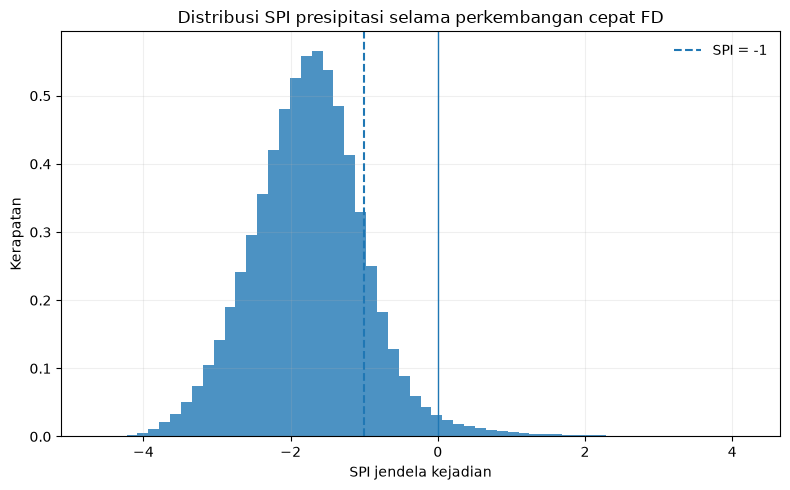

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(valid_events["spi_dev"], bins=60, density=True, alpha=0.8)
ax.axvline(SPI_THRESHOLD, linestyle="--", linewidth=1.5, label="SPI = -1")
ax.axvline(0, linewidth=1.0)
ax.set(
    xlabel="SPI jendela kejadian",
    ylabel="Kerapatan",
    title="Distribusi SPI presipitasi selama perkembangan cepat FD",
)
ax.legend(frameon=False)
ax.grid(alpha=0.2)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "figure_SPI_event_distribution.png", dpi=250, bbox_inches="tight")
plt.show()


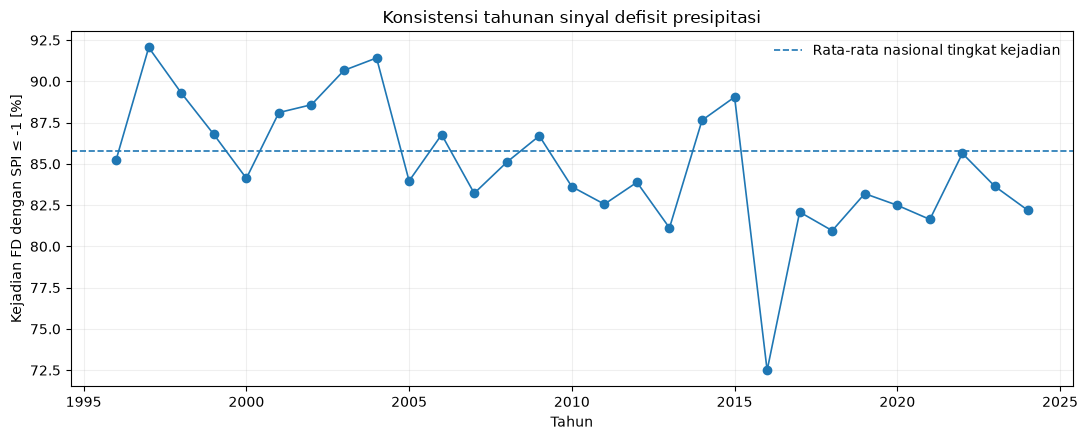

In [12]:
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(
    annual_summary["year"],
    annual_summary["spi_le_minus1_pct"],
    marker="o",
    linewidth=1.2,
)
ax.axhline(
    national_summary.loc[0, "spi_le_minus1_pct"],
    linestyle="--",
    linewidth=1.2,
    label="Rata-rata nasional tingkat kejadian",
)
ax.set(
    xlabel="Tahun",
    ylabel="Kejadian FD dengan SPI ≤ -1 [%]",
    title="Konsistensi tahunan sinyal defisit presipitasi",
)
ax.grid(alpha=0.2)
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "figure_SPI_deficit_fraction_by_year.png", dpi=250, bbox_inches="tight")
plt.show()


## 9. Simpan output

REV1-03 sengaja **tidak membuat klasifikasi Compound/PET** karena data PET belum tersedia. Nanti REV1-04 akan menggabungkan:

- `spi_dev <= -1`, dan
- standardized PET anomaly `>= +1`

pada **jendela rapid-development yang identik**.


In [13]:
event_out = OUTPUT_DIR / "event_level_SPI_christian_style.parquet"
national_out = OUTPUT_DIR / "national_SPI_summary.csv"
annual_out = OUTPUT_DIR / "annual_SPI_summary.csv"
onset_out = OUTPUT_DIR / "SPI_summary_by_onset_duration.csv"
qc_group_out = OUTPUT_DIR / "SPI_QC_by_calendar_window.csv"

events_spi.to_parquet(event_out, index=False)
national_summary.to_csv(national_out, index=False)
annual_summary.to_csv(annual_out, index=False)
onset_summary.to_csv(onset_out, index=False)
spi_qc_by_group.to_csv(qc_group_out, index=False)

manifest = {
    "version": "REV1_03_SPI_CHRISTIAN_STYLE_v3_MISSING_SAFE",
    "analysis_period": [ANALYSIS_START, ANALYSIS_END],
    "climatology_period": [CLIM_START, CLIM_END],
    "event_input": str(event_source),
    "detection_file": str(DETECTION_FILE),
    "precipitation_dir": str(PRECIP_DIR),
    "precipitation_variable": P_VAR,
    "row_definition": "one row = one grid-cell M2A flash-drought start",
    "fd_detection_role": "RZSM benchmark only; SPI is a post-detection driver diagnostic",
    "driver_window": (
        "pentads after RZSM baseline through first <P20 threshold crossing; "
        "length = onset_time_pentads"
    ),
    "spi_type": "event-window SPI",
    "spi_distribution": "gamma with zero-precipitation correction",
    "spi_large_deficit_threshold": SPI_THRESHOLD,
    "minimum_climatology_samples": MIN_CLIM_SAMPLES,
    "missing_precipitation_policy": (
        "Missing precipitation is never treated as zero. Event/climatology windows "
        "are valid only when all pentads in the window are present; incomplete "
        "climatology samples are omitted grid-wise."
    ),
    "reference_method": (
        "Adapted from Christian et al. (2021) driver analysis: accumulated "
        "precipitation over each flash-drought development time frame and SPI "
        "calculated against climatology over the same time frame."
    ),
    "reference_doi": "10.1038/s41467-021-26692-z",
    "interpretation": (
        "precipitation-supply diagnostic association; not causal attribution"
    ),
    "future_merge": (
        "REV1-04 should combine spi_dev with standardized FAO-56 PET anomaly "
        "using the identical event window."
    ),
}

(OUTPUT_DIR / "manifest_REV1_03_SPI_v2_FIXED.json").write_text(
    json.dumps(manifest, indent=2),
    encoding="utf-8",
)

print("DONE")
print("Tabel kejadian tersimpan:", event_out)
print("Ringkasan tersimpan di:", OUTPUT_DIR)


DONE
Tabel kejadian tersimpan: D:\ERA5_LAND\output_fd_REV1_03_SPI\event_level_SPI_christian_style.parquet
Ringkasan tersimpan di: D:\ERA5_LAND\output_fd_REV1_03_SPI


# STOP DI SINI

Setelah notebook selesai dijalankan, kirim ke saya tiga output berikut sebelum kita membuat REV1-04 PET:

1. `national_SPI_summary.csv`
2. `SPI_summary_by_onset_duration.csv`
3. `SPI_QC_by_calendar_window.csv`

Yang akan kita cek terlebih dahulu:

- persentase valid SPI;
- apakah jumlah sampel klimatologi cukup pada semua calendar-window;
- proporsi `SPI <= -1`;
- apakah hasil sangat sensitif terhadap panjang onset;
- baru setelah itu SPI digabung dengan PET.
